Neural Networks (iPython Notebook)
==================================
This notebook includes examples of basics on neural networks, i.e. how to train ANNs and how to make use of them. We will first build a network completeley from scratch (without libraries) to see in more detail how it works. After that, we use libraries.

**General introduction**

The human learning process is hierarchical. We have various stages in our brain's neural network and each stage corresponds to a different granularity. Some stages learn simple things and some stages learn more complex things. Let's consider an example of visually recognizing an object. When we look at a box, the first stage identifies simple things like corners and edges. The next stage identifies the generic shape and the stage after that identifies what kind of object it is. This process differs for different tasks, but you get the idea! By building this hierarchy, our human brain quickly separates the concepts and identifies the given object.

To simulate the learning process of the human brain, an artificial neural network is built using layers of neurons. These neurons are inspired by the biological neurons we discussed in the previous paragraph. Each layer in an artificial neural network is a set of independent neurons. Each neuron in a layer is connected to neurons in the adjacent layer.

**Training the network**

If we are dealing with N-dimensional input data, then the input layer will consist of N neurons. If we have M distinct classes in our training data, then the output layer will consist of M neurons. The layers between the input and output layers are called hidden layers. A simple neural network will consist of a couple of layers and a deep neural network will consist of many layers.

Consider the case where we want to use a neural network to classify the given data. The first step is to collect the appropriate training data and label it. Each neuron acts as a simple function and the neural network trains itself until the error goes below a certain value. The error is basically the difference between the predicted output and the actual output. Based on how big the error is, the neural network adjusts itself and retrains until it gets closer to the solution.

**Building a Perceptron**

A Perceptron is the building block of an artificial neural network. It is a single neuron that takes inputs, performs computation on them, and then produces an output. It uses a simple linear function to make the decision. Let's say we are dealing with an N-dimension input data point. A Perceptron computes the weighted summation of those N numbers and it then adds a constant to produce the output. The constant is called the bias of the neuron. It is remarkable to note that these simple Perceptrons are used to design very complex deep neural networks.

Building a neural network manually
-----------------------------------------------------------------
The following example demonstrates how to build a neural network without using a library. Precisely we want to build a NN for simulating the following behavior: XOR with three input chanels (if two chanels are 1 the output should be 1; in all other cases the output is 0). The NN accepts three input values, has one hidden layer with 4 neurons and one output chanel. Activation function is (always) sigmoid.

In [1]:
import numpy as np

# sigmoid and derivation of sigmoid as functions
def sigmoid(x):
    return 1.0/(1+ np.exp(-x))

def sigmoid_derivative(x):
    return x * (1.0 - x)

# neural network packed in a class
class NeuralNetwork:
    def __init__(self, x, y):
        self.input      = x
        self.weights1   = np.random.rand(self.input.shape[1],4) 
        self.weights2   = np.random.rand(4,1)                 
        self.y          = y
        self.output     = np.zeros(self.y.shape)

    def feedforward(self):
        self.layer1 = sigmoid(np.dot(self.input, self.weights1))
        self.output = sigmoid(np.dot(self.layer1, self.weights2))

    def backprop(self):
        # application of the chain rule to find derivative of the loss function with respect to weights2 and weights1
        d_weights2 = np.dot(self.layer1.T, (2*(self.y - self.output) * sigmoid_derivative(self.output)))
        d_weights1 = np.dot(self.input.T,  (np.dot(2*(self.y - self.output) * sigmoid_derivative(self.output), self.weights2.T) * sigmoid_derivative(self.layer1)))
        
        # update the weights with the derivative (slope) of the loss function
        self.weights1 += d_weights1
        self.weights2 += d_weights2

Next, we define some training data and feed it into the network. For each training sample we compute the output and perform the backpropagation to train the network.

In [2]:
# input data: 5 vectors in binary form
X = np.array([[0,0,1],
              [1,1,0],
              [1,0,1],
              [0,1,1],
              [1,1,1]])

# output values (labels)
y = np.array([[0],[1],[1],[1],[0]])

# initialize neural network
nn = NeuralNetwork(X, y)

# iterate 1500 times
for i in range(1500):
    nn.feedforward()
    nn.backprop()

print('Input:', X)
print('\nExpected output:', y)
print('\nPredicted output:', nn.output)

Input: [[0 0 1]
 [1 1 0]
 [1 0 1]
 [0 1 1]
 [1 1 1]]

Expected output: [[0]
 [1]
 [1]
 [1]
 [0]]

Predicted output: [[0.00343599]
 [0.98868921]
 [0.98034991]
 [0.97625871]
 [0.02973345]]


As we can see, the network learned to fit the training data very well as the predicted output is close to the expected one.

### Exercise 4.1: Experiment with this 2-layer neural network
Based on the above template, change
- the number of neurons in the hidden layer,
- the activation function (sigmoid vs linear vs tanH), and
- the number of training iterations

and observe how it affects the error/delta. You may also add some debug output in the backpropagation function (e.g. intermediate results after 100 training runs).

Building a Perceptron based Classifier using Library NeuroLab
--------------------------------------
While the above network was built from scratch, we will now use a library. For now we use *NeuroLab* (less well-known, but simpler), while the famous library *TensorFlow* is used in the next notebook.

We build networks with increasing complexity in three steps:
- First, we build a **perceptron**, i.e., a network consisting of a single unit.
- Second, we build a **single-layer network**, i.e., a network with multiple units but which are arranged in a single hidden layer.
- Third, we build a **multi-layer network**, i.e., a network with multiple hidden layers, each of which consisting of multiple units.

Let's start with building a Perceptron based classifier using NeuroLab. We first read data points from a file a visualize it.

Text(0.5, 1.0, 'Input data')

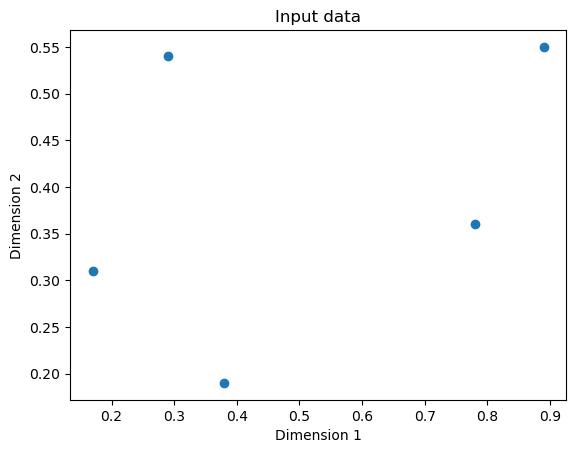

In [3]:
# to be installed first: > pip3 install neurolab
import numpy as np
import matplotlib.pyplot as plt
import neurolab as nl

# Load input data 
text = np.loadtxt('04_data_perceptron.txt')

# Separate datapoints and labels
data = text[:, :2]
labels = text[:, 2].reshape((text.shape[0], 1))

# Plot input data
plt.figure()
plt.scatter(data[:,0], data[:,1])
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Input data')

We now extract the ranges of data values (minimum and maximum in both dimensions). This is because the NeuroLab library expects us to define the ranges, as well as the number of outputs, when we instantiate the perceptron class in the last line of the following code.

**Important:** NN libraries usually support *a lot* of different parameters! This might be confusing at first glance. Therefore, as a beginner one should not focus on these details, but focus on the overall pipleline of: **instantiate the classifier, train it, and test it**. In fact, dealing and experimenting with all the parameters and configuration options to find the ones that work best, is what causes the most effort when working on a realistic AI application.

In [4]:
# Define minimum and maximum values for each dimension
dim1_min, dim1_max, dim2_min, dim2_max = 0, 1, 0, 1

# Number of neurons in the output layer
num_output = labels.shape[1]

# Define a perceptron with 2 input neurons (because we 
# have 2 dimensions in the input data)
dim1 = [dim1_min, dim1_max]
dim2 = [dim2_min, dim2_max]
perceptron = nl.net.newp([dim1, dim2], num_output)

We now train the network and visualize the training progress over time.

The goal of learning is reached


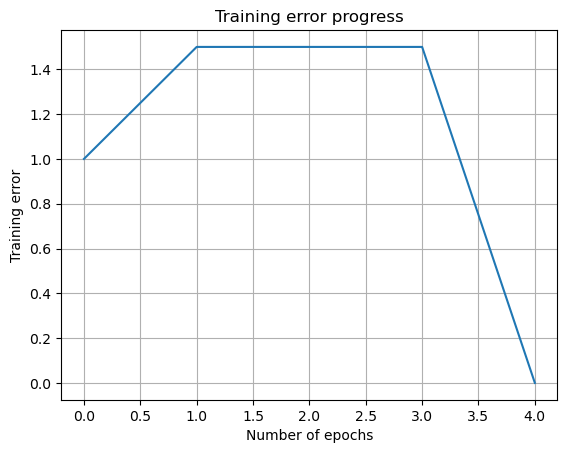

In [5]:
# Train the perceptron using the data (lr...learning rate)
error_progress = perceptron.train(data, labels, epochs=100, show=20, lr=0.03)

# Plot the training progress
plt.figure()
plt.plot(error_progress)
plt.xlabel('Number of epochs')
plt.ylabel('Training error')
plt.title('Training error progress')
plt.grid()

plt.show()

As one can see, the training error goes down with the number of iterations. However, it is normally not *strictly* decreasing, but may also go up and down for a while (oscillation). But it is important to decrease in the long run.

### Exercise 4.2: Build a perceptron on a spiral pattern

In this exercise, use the above perceptron classifier, i.e. **a single neuron**, and train it on the following spiral data set. What do you observe?

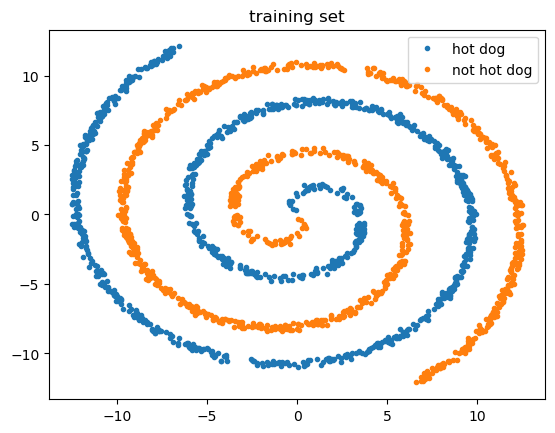

In [11]:
def twospirals(n_points, noise=.5):
    """
     Returns the two spirals dataset.
    """
    n = np.sqrt(np.random.rand(n_points,1)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_points,1) * noise
    d1y = np.sin(n)*n + np.random.rand(n_points,1) * noise
    return (np.vstack((np.hstack((d1x,d1y)),np.hstack((-d1x,-d1y)))), 
            np.hstack((np.zeros(n_points),np.ones(n_points))))

X, y = twospirals(1000)

plt.title('training set')
plt.plot(X[y==0,0], X[y==0,1], '.', label='hot dog')
plt.plot(X[y==1,0], X[y==1,1], '.', label='not hot dog')
plt.legend()
plt.show()

Constructing a single layer neural network
------------------------------------------
A perceptron is a good start, but as we have seen it cannot do much as it has problems with data that is not linearly separable.

The next step is to have multiple independent neurons acting on input data to produce the output (hidden layer). Note that we **still have only one hidden layer**, but this layer consists of multiple neurons.

Text(0.5, 1.0, 'Input data')

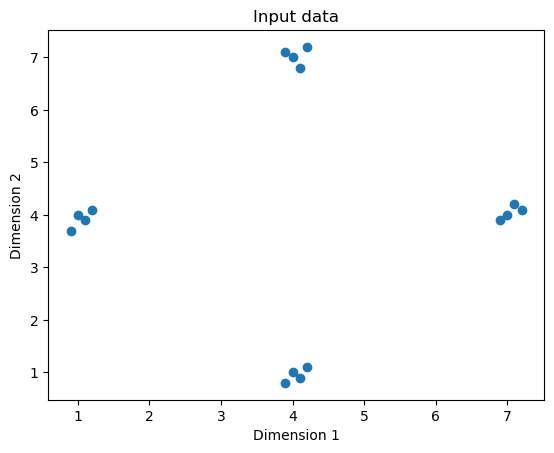

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import neurolab as nl

# Load input data
text = np.loadtxt('04_data_simple_nn.txt')

# Separate it into datapoints and labels
data = text[:, 0:2]
labels = text[:, 2:]
labeldict = [ [ "left", "right" ], ["bottom", "top"] ]

# Plot input data
plt.figure()
plt.scatter(data[:,0], data[:,1])

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Input data')

We have data points in four clusters:
- The **features** of each point are its x/y coordinates (2-dimensional).
- The **label** of each point is also a 2-dimensional vector of 0/1. It defines to which cluster the point belongs using the following schema: [0, 0] = left cluster, [0, 1] = right cluster, [1, 0] = bottom cluster, [1, 1] = top cluster.

Our goal will be to predict a point's label based on its coordinates.

In [82]:
print("Data:\n", data, "\nLabels:\n", np.array([ [x, y, labeldict[int(x)][int(y)] ] for [x, y] in labels]))

Data:
 [[1.  4. ]
 [1.1 3.9]
 [1.2 4.1]
 [0.9 3.7]
 [7.  4. ]
 [7.2 4.1]
 [6.9 3.9]
 [7.1 4.2]
 [4.  1. ]
 [4.1 0.9]
 [4.2 1.1]
 [3.9 0.8]
 [4.  7. ]
 [4.2 7.2]
 [3.9 7.1]
 [4.1 6.8]] 
Labels:
 [['0.0' '0.0' 'left']
 ['0.0' '0.0' 'left']
 ['0.0' '0.0' 'left']
 ['0.0' '0.0' 'left']
 ['0.0' '1.0' 'right']
 ['0.0' '1.0' 'right']
 ['0.0' '1.0' 'right']
 ['0.0' '1.0' 'right']
 ['1.0' '0.0' 'bottom']
 ['1.0' '0.0' 'bottom']
 ['1.0' '0.0' 'bottom']
 ['1.0' '0.0' 'bottom']
 ['1.0' '1.0' 'top']
 ['1.0' '1.0' 'top']
 ['1.0' '1.0' 'top']
 ['1.0' '1.0' 'top']]


Again, we need to extract the ranges and instantiate the classifier.

In [86]:
# Minimum and maximum values for each dimension
dim1_min, dim1_max = data[:,0].min(), data[:,0].max()
dim2_min, dim2_max = data[:,1].min(), data[:,1].max()

# Define the number of neurons in the output layer
num_output = labels.shape[1]

# Define a single-layer neural network with 5 neurons in the hidden layer
dim1 = [dim1_min, dim1_max]
dim2 = [dim2_min, dim2_max]
nn = nl.net.newff([dim1, dim2], [5, num_output])

Once more, we train the network and visualize its training progress.

Epoch: 20; Error: 0.4827056919805924;
Epoch: 40; Error: 0.012367562063284793;
The goal of learning is reached


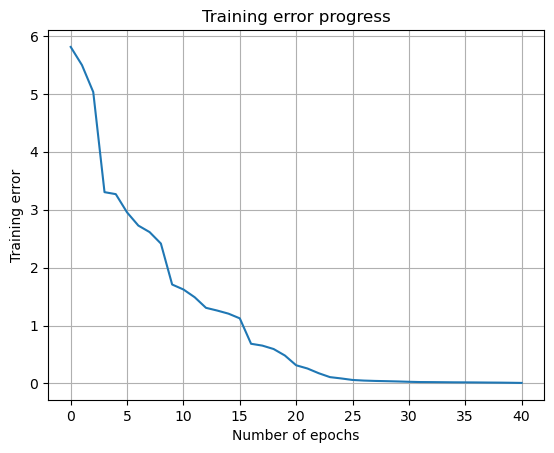

In [87]:
# Train the neural network
error_progress = nn.train(data, labels, epochs=100, show=20)

# Plot the training progress
plt.figure()
plt.plot(error_progress)
plt.xlabel('Number of epochs')
plt.ylabel('Training error')
plt.title('Training error progress')
plt.grid()

plt.show()

We see that the error goes down over the number of epochs, which is as desired.

Now let's test it on a couple of data points and see that the network outputs. That is, based on coordinates of new data points, we predict its cluster.

In [88]:
# Run the classifier on test datapoints
print('\nTest results:')
data_test = [[0.4, 4.3], [4.4, 0.6], [4.7, 8.1]]
for item in data_test:
    print(item, '-->', nn.sim([item])[0], '-->', 'class:', labeldict[ round(nn.sim([item])[0][0])][round(nn.sim([item])[0][1]) ])


Test results:
[0.4, 4.3] --> [ 0.07513091 -0.00761165] --> class: left
[4.4, 0.6] --> [ 0.99238556 -0.01040552] --> class: bottom
[4.7, 8.1] --> [0.96297581 0.98329926] --> class: top


Constructing a multilayer neural network
----------------------------------------
In order to enable higher accuracy, we need to give more freedom to the neural network. This means that a neural network needs more than one layer to extract the underlying patterns in the training data.

Let's create a multilayer neural network to achieve that. Our feature of each data point is now the x-coordinate, and its label is its y-coordinate. That is, we want to train a network that predicts the y-ccordinate based on the x-coordinate.

Text(0.5, 1.0, 'Input data')

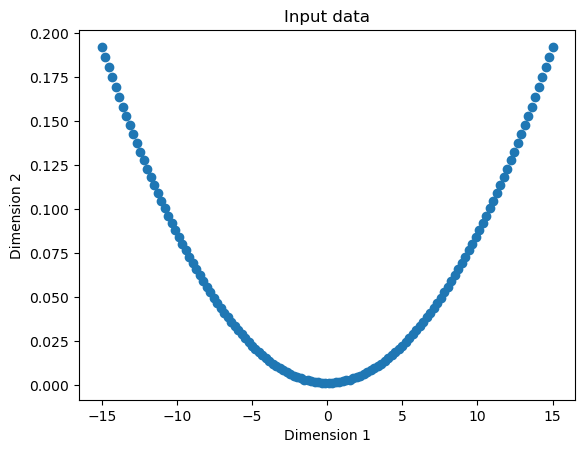

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import neurolab as nl

# Generate some training data
min_val = -15
max_val = 15
num_points = 130
x = np.linspace(min_val, max_val, num_points)
y = 3 * np.square(x) + 5
y /= np.linalg.norm(y)

# Create data and labels
data = x.reshape(num_points, 1)
labels = y.reshape(num_points, 1)

# Plot input data
plt.figure()
plt.scatter(data, labels)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Input data')

Let's create the network:

In [90]:
# Define a multilayer neural network with 2 hidden layers;
# First hidden layer consists of 10 neurons
# Second hidden layer consists of 6 neurons
# Output layer consists of 1 neuron
nn = nl.net.newff([[min_val, max_val]], [10, 6, 1])

# Set the training algorithm to gradient descent
nn.trainf = nl.train.train_gd

And train it:

Epoch: 100; Error: 1.6985097796558004;
Epoch: 200; Error: 0.02008984547992622;
Epoch: 300; Error: 0.017832259223217968;
Epoch: 400; Error: 0.016408177414378403;
Epoch: 500; Error: 0.01532208681037997;
Epoch: 600; Error: 0.014474277840057663;
Epoch: 700; Error: 0.013799150091368678;
Epoch: 800; Error: 0.013249392257463943;
Epoch: 900; Error: 0.012803298808199404;
Epoch: 1000; Error: 0.012864642044835986;
Epoch: 1100; Error: 0.041331799246160233;
Epoch: 1200; Error: 0.028108137980197154;
Epoch: 1300; Error: 0.01231164165524768;
Epoch: 1400; Error: 0.011438181571971694;
Epoch: 1500; Error: 0.011156216620839146;
Epoch: 1600; Error: 0.010950705574995346;
Epoch: 1700; Error: 0.010857320436496643;
Epoch: 1800; Error: 0.012149203275524849;
Epoch: 1900; Error: 0.03630821822742582;
Epoch: 2000; Error: 0.020592529685761356;
The maximum number of train epochs is reached


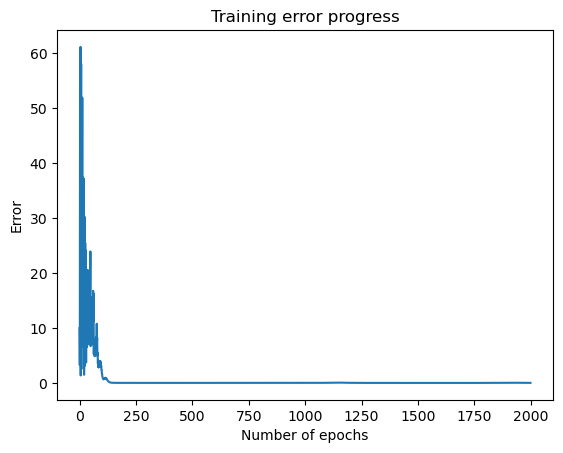

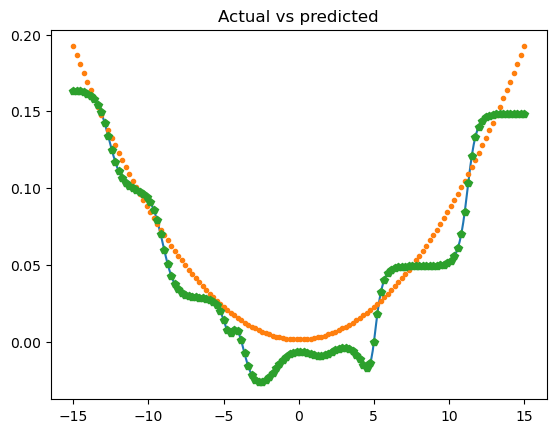

In [91]:
# Train the neural network
error_progress = nn.train(data, labels, epochs=2000, show=100, goal=0.01)

# Run the neural network on training datapoints
output = nn.sim(data)
y_pred = output.reshape(num_points)

# Plot training error
plt.figure()
plt.plot(error_progress)
plt.xlabel('Number of epochs')
plt.ylabel('Error')
plt.title('Training error progress')

# Plot the output 
x_dense = np.linspace(min_val, max_val, num_points * 2)
y_dense_pred = nn.sim(x_dense.reshape(x_dense.size,1)).reshape(x_dense.size)

plt.figure()
plt.plot(x_dense, y_dense_pred, '-', x, y, '.', x, y_pred, 'p')
plt.title('Actual vs predicted')

plt.show()

As we can see, the prediction is far from perfect, but the network did definitely learn the general pattern.

### Exercise 4.3: Build a multilayer neural network and train it with the spiral data from above. What do you observe now?

Application: Experiments with Large Language Models
----------------------------------------

### Exercise 4.4: Use a state-of-the-art Chatbot based on an LLM (ChatGPT, LLaMA, Gemini, etc) and force it to give a wrong answer. Make sure that there is no room for interpretation or different opinions, but that the answer is objectively wrong.
(There are many possible answers, but no reference solution can be provided because of fast ongoing changes and improvements of these systems.)